## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import random

%matplotlib inline

### Dataset

In [2]:
xs = [x for x in range(-15, 16)]
ys = [(5.0*x - 7.5) + random.randrange(-20, 20) for x in xs]

In [3]:
ys_best_fit = [(5.0*x - 7.5) for x in xs]

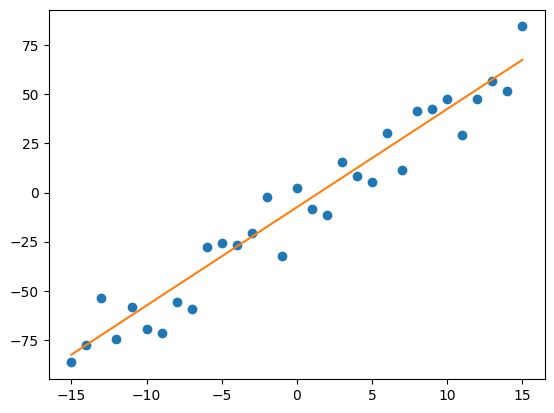

In [4]:
plt.plot(xs, ys, 'o')
plt.plot(xs, ys_best_fit)
plt.show()

Visualize these different optimizers: Iterations vs Cost

In [5]:
def calc_mse_loss(y_target, y_pred):  
  N = len(y_target)
  total_loss = sum([(1 / N)*(y_target[i] - y_pred[i])**2 for i in range(N)])
  return total_loss

In [6]:
def train(w, b, xs, ys, optimizer, lr=0.003, epochs=1000):
  history = [] # Loss over each training step

  for ep in range(epochs):    
    y_pred = [w*x + b for x in xs]
    w, b = optimizer(w, b, xs, ys, lr) 
    loss = calc_mse_loss(ys, y_pred)
    history.append(loss)

  return w, b, history

### Batch Gradient Descent

In [7]:
# Computes gradient using entire training dataset
def batch_gd(w, b, xs, y_target, lr):
  N = len(xs)
  y_pred = [w*x + b for x in xs]

  # dw = (-2 / N) * SUM((y_target - y_pred) * x)
  dw = (-2.0 / N) * sum([(y_target[i] - y_pred[i]) * xs[i] for i in range(N)])
  # db = (-2 / N) * SUM(y_target - y_pred)
  db = (-2.0 / N) * sum([(y_target[i] - y_pred[i]) for i in range(N)])

  # Update parameters
  w -= lr*dw
  b -= lr*db

  return w, b

### SGD

In [20]:
def sgd(w, b, xs, y_target, lr):
  N = len(xs)

  # Update parameters for each individual x,y in training data
  for i in range(N):
    y_pred = w*xs[i] + b

    dw = (-2.0) * (y_target[i] - y_pred) * xs[i]
    db = (-2.0) * (y_target[i] - y_pred)

    w -= lr*dw
    b -= lr*db

  return w, b

### Mini-batch Gradient Descent

In [9]:
def generate_batches(x, y, batch_size):
  N = len(x)
  x_b = []
  y_b = []

  for i in range(0, N, batch_size):
    curr_batch_x = []
    curr_batch_y = []

    if i + batch_size <= N:
      curr_batch_x = [x[j] for j in range(i, i+batch_size)]
      curr_batch_y = [y[j] for j in range(i, i+batch_size)]
    else:
      curr_batch_x = [x[j] for j in range(i, N)]
      curr_batch_y = [y[j] for j in range(i, N)]
    
    x_b.append(curr_batch_x)
    y_b.append(curr_batch_y)

  return x_b, y_b

In [10]:
def mini_batch_gd(w, b, xs, y_target, lr):  
  # Update parameters for batches of the data
  x_b, y_b = generate_batches(xs, y_target, 8)

  for xi, yi in zip(x_b, y_b):
    bN = len(xi)
    y_pred = [w*xi[i] + b for i in range(bN)]

    # dw = (-2 / N) * SUM((y_target - y_pred) * x)
    dw = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) * xi[i] for i in range(bN)])
    # db = (-2 / N) * SUM(y_target - y_pred)
    db = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) for i in range(bN)])

    w -= lr*dw
    b -= lr*db
  
  return w, b

In [21]:
# Batch GD
w_1 = random.random()
b_1 = 0.0
w_1, b_1, bgd_history = train(w_1, b_1, xs, ys, batch_gd)

# Mini-batch GD
w_2 = random.random()
b_2 = 0.0
w_2, b_2, mb_history = train(w_2, b_2, xs, ys, mini_batch_gd)

# SGD
w_3 = random.random()
b_3 = 0.0
w_3, b_3, sgd_history = train(w_3, b_3, xs, ys, sgd, lr=0.001)

### Momentum
- Momentum helps accelerate SGD in the relevant direction and dampens oscillations.
- Momentum term increases for dimensions whose gradients point in the same directions and reduces updates for dimensions whose gradients change directions. As a result, we gain faster convergence and reduced oscillation.

### RMSprop 
- Root Mean Square Propagation

Algorithm:
- $v_t = \beta v_{t-1} + (1 - \beta) * g_t^2$
- $w_{t+1} = w_{t} - \frac{η}{\sqrt{v_t} + ϵ} * g_t$

- $v_t$, $b_t$ are initialized to 0.

- $v_t$ is the moving average of the squared gradients.
- $β$ is a hyperparameter that controls decay rate of the moving average.
- $η$ is the learning rate
- $ϵ$ is a small constant added to the denominator to prevent division by zero.

In [14]:
def rms_prop(w, b, xs, y_target, lr, epochs=1000, beta=0.9, epsilon=1e-8):
  # Store losses at each iteration
  history = []

  x_b, y_b = generate_batches(xs, y_target, 8)
  v_w = 0.0
  v_b = 0.0

  for ep in range(epochs):
    for xi, yi in zip(x_b, y_b):
      bN = len(xi)
      y_pred = [w*xi[i] + b for i in range(bN)]

      dw = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) * xi[i] for i in range(bN)])
      v_w = beta*v_w + (1 - beta)*(dw**2)

      db = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) for i in range(bN)])
      v_b = beta*v_b + (1 - beta)*(db**2)

      w -= (lr / (v_w**0.5 + epsilon))*dw
      b -= (lr / (v_b**0.5 + epsilon))*db
    
    y_pred = [w*xs[i] + b for i in range(len(xs))]
    loss = calc_mse_loss(ys, y_pred)
    history.append(loss)

  return w, b, history

In [15]:
# RMSprop
w_4 = random.random()
b_4 = 0.0
w_4, b_4, rmsprop_history = rms_prop(w_4, b_4, xs, ys, 0.01)

### Adam

- Adaptive Moment Estimation.
- Computes adaptive learning rates for each parameter. 
- It keeps an exponentially decaying average of past gradients $m_t$, similar to momentum.

$m_t = β_1 m_{t-1} + (1 - β_1)g_t$

$v_t = β_2 v_{t-1} + (1 - β_2)g_t^2$

$m_t$ and $v_t$ are estimates of the first moment (the mean) and the second moment (the uncentered variance) of the gradients respectively. 

We divide these by $1 - β^t$ to do bias correction.

$\hat{m_t} = \frac{m_t}{1 - β_1^t}$

$\hat{v_t} = \frac{v_t}{1 - β_2^t}$

Parameter updates:
- $θ_{t+1} = θ_t - \frac{η}{\sqrt{\hat{v_t}} + ϵ}\hat{m_t}$

The authors for the Adam paper proposed default values of 
- 0.9 for β_1
- 0.999 for β_2
- $10^{-8}$ for ϵ.

In [17]:
def adam_opt(w, b, xs, y_target, lr, epochs=1000, beta_1=0.9, beta_2=0.999, epsilon=1e-8):
  # Store losses at each iteration
  history = []

  x_b, y_b = generate_batches(xs, y_target, 8)
  m_w = 0.0
  v_w = 0.0  

  m_b = 0.0
  v_b = 0.0

  for ep in range(1, epochs+1):
    for xi, yi in zip(x_b, y_b):
      bN = len(xi)
      y_pred = [w*xi[i] + b for i in range(bN)]

      dw = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) * xi[i] for i in range(bN)])
      db = (-2.0 / bN) * sum([(yi[i] - y_pred[i]) for i in range(bN)])

      # First moments (mean)
      m_w = beta_1*m_w + (1 - beta_1)*dw
      m_b = beta_1*m_b + (1 - beta_1)*db

      # Second moments (uncentered variance)
      v_w = beta_2*v_w + (1 - beta_2)*dw**2
      v_b = beta_2*v_b + (1 - beta_2)*db**2

      # bias correction
      mw_hat = m_w / (1 - beta_1**ep)
      mb_hat = m_b / (1 - beta_1**ep)
      vw_hat = v_w / (1 - beta_2**ep)
      vb_hat = v_b / (1 - beta_2**ep)

      w -= (lr / (vw_hat**0.5 + epsilon))*mw_hat
      b -= (lr / (vb_hat**0.5 + epsilon))*mb_hat
    
    y_pred = [w*xs[i] + b for i in range(len(xs))]
    loss = calc_mse_loss(ys, y_pred)
    history.append(loss)

  return w, b, history

In [18]:
# Adam
w_5 = random.random()
b_5 = 0.0
w_5, b_5, adam_history = adam_opt(w_5, b_5, xs, ys, 0.01)

### Loss vs. Iterations

Batch Gradient Descent: 5.023790322580645 -9.21943730683985
Mini-batch Gradient Descent: 5.048394532116647 -9.060883454542953
SGD: 5.357032288155995 -8.718580267601265
RMSprop: 5.032189796195761 -9.204360955854542
Adam: 5.02105667226924 -8.241408722415192


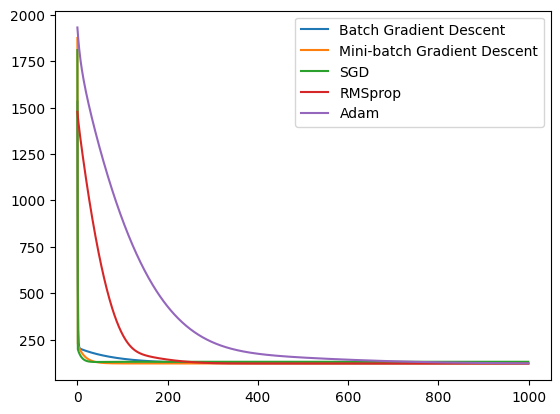

In [22]:
iterations = [i for i in range(1000)]

plt.plot(iterations, bgd_history, label='Batch Gradient Descent')
plt.plot(iterations, mb_history, label='Mini-batch Gradient Descent')
plt.plot(iterations, sgd_history, label='SGD')
plt.plot(iterations, rmsprop_history, label='RMSprop')
plt.plot(iterations, adam_history, label='Adam')
plt.legend()

print("Batch Gradient Descent:", w_1, b_1)
print("Mini-batch Gradient Descent:", w_2, b_2)
print("SGD:", w_3, b_3)
print("RMSprop:", w_4, b_4)
print("Adam:", w_5, b_5)

plt.show()